# Sun Belt Football Spending & Performance Analysis

### Excel & Python Companion Analysis

This notebook reproduces and extends an Excel-based analysis of football spending and on-field performance across 14 NCAA Division I Sun Belt programs.

## Project Overview

The project compares football program spending with on-field performance across 14 Sun Belt Conference programs.

The Python analysis was designed to:

- import and validate the Excel dataset;
- independently recalculate key performance and efficiency metrics;
- rank programs by spending efficiency;
- examine correlations between football spending and performance;
- visualize the main relationships identified in the data.

## Data Sources & Methodology

Financial data were sourced from the U.S. Department of Education EADA dataset, while football performance data were sourced from Sun Belt Conference results.

The detailed methodology, source references, reporting periods, and metric definitions are documented in the accompanying Excel workbook.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

## Data Import

The analysis uses the cleaned `Data` worksheet from the accompanying Excel workbook. The workbook is loaded using a relative project path to keep the notebook portable.

In [2]:
file_path = Path(
    "../data/Aurelien_Schmitt_Sun_Belt_Football_Analytics_Project.xlsx"
)

excel_file = pd.ExcelFile(file_path)
excel_file.sheet_names

['Data', 'analysis', 'dashboard', 'Methodology & Sources', 'Raw Data']

In [3]:
df = pd.read_excel(file_path, sheet_name="Data")

## Data Inspection

The dataset structure, dimensions, data types, and completeness were reviewed before analysis.

In [4]:
df.head()

,University,Division,Football participants,Total Football expenses,Overall wins,Overall losses,Conference wins,Conference losses,Expenses per participant,Overall win percentage,Conference win percentage,Wins per $1M spent,Conference wins per $1M spent,Financial data source,Sport results source
0,Appalachian State University,East,122,13288981,9,5,6,2,108926.073770,0.642857,0.750,0.677253,0.451502,U.S. Department of Education — EADA Survey Yea...,Sun Belt Conference – 2023 Football Standings
1,Arkansas State University,West,153,11536628,6,7,4,4,75402.797386,0.461538,0.500,0.520083,0.346722,U.S. Department of Education — EADA Survey Yea...,Sun Belt Conference – 2023 Football Standings
2,Coastal Carolina University,East,123,17052582,8,5,5,3,138638.878049,0.615385,0.625,0.469137,0.293211,U.S. Department of Education — EADA Survey Yea...,Sun Belt Conference – 2023 Football Standings
3,Georgia Southern University,East,146,11225441,6,7,3,5,76886.582192,0.461538,0.375,0.534500,0.267250,U.S. Department of Education — EADA Survey Yea...,Sun Belt Conference – 2023 Football Standings
4,Georgia State University,East,118,12260120,7,6,3,5,103899.322034,0.538462,0.375,0.570957,0.244696,U.S. Department of Education — EADA Survey Yea...,Sun Belt Conference – 2023 Football Standings


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   University                     14 non-null     str    
 1   Division                       14 non-null     str    
 2   Football participants          14 non-null     int64  
 3   Total Football expenses        14 non-null     int64  
 4   Overall wins                   14 non-null     int64  
 5   Overall losses                 14 non-null     int64  
 6   Conference wins                14 non-null     int64  
 7   Conference losses              14 non-null     int64  
 8   Expenses per participant       14 non-null     float64
 9   Overall win percentage         14 non-null     float64
 10  Conference win percentage      14 non-null     float64
 11  Wins per $1M spent             14 non-null     float64
 12  Conference wins per $1M spent  14 non-null     float64
 13  Fin

In [6]:
df.isna().sum().sum()

np.int64(0)

## Data Preparation

Only the variables required to independently reproduce the performance and efficiency metrics were retained. Column names were then standardized for easier analysis in pandas.

In [7]:
base_df = df[
    [
        "University",
        "Division",
        "Football participants",
        "Total Football expenses",
        "Overall wins",
        "Overall losses",
        "Conference wins",
        "Conference losses"
    ]
].copy()

In [8]:
base_df = base_df.rename(columns={
    "University": "university",
    "Division": "division",
    "Football participants": "participants",
    "Total Football expenses": "football_expenses",
    "Overall wins": "wins",
    "Overall losses": "losses",
    "Conference wins": "conference_wins",
    "Conference losses": "conference_losses"
})

In [9]:
base_df.head()

,university,division,participants,football_expenses,wins,losses,conference_wins,conference_losses
0,Appalachian State University,East,122,13288981,9,5,6,2
1,Arkansas State University,West,153,11536628,6,7,4,4
2,Coastal Carolina University,East,123,17052582,8,5,5,3
3,Georgia Southern University,East,146,11225441,6,7,3,5
4,Georgia State University,East,118,12260120,7,6,3,5


## KPI Calculation

Five performance and efficiency metrics were independently recalculated in Python from the underlying spending and results data.

In [10]:
base_df["expenses_per_participant"] = (
    base_df["football_expenses"] / base_df["participants"]
)

base_df["win_percentage"] = (
    base_df["wins"] /
    (base_df["wins"] + base_df["losses"])
)

base_df["conference_win_percentage"] = (
    base_df["conference_wins"] /
    (base_df["conference_wins"] + base_df["conference_losses"])
)

base_df["wins_per_million"] = (
    base_df["wins"] /
    (base_df["football_expenses"] / 1_000_000)
)

base_df["conference_wins_per_million"] = (
    base_df["conference_wins"] /
    (base_df["football_expenses"] / 1_000_000)
)

In [11]:
base_df[[
    "university",
    "expenses_per_participant",
    "win_percentage",
    "conference_win_percentage",
    "wins_per_million",
    "conference_wins_per_million"
]].head()

,university,expenses_per_participant,win_percentage,conference_win_percentage,wins_per_million,conference_wins_per_million
0,Appalachian State University,108926.073770,0.642857,0.750,0.677253,0.451502
1,Arkansas State University,75402.797386,0.461538,0.500,0.520083,0.346722
2,Coastal Carolina University,138638.878049,0.615385,0.625,0.469137,0.293211
3,Georgia Southern University,76886.582192,0.461538,0.375,0.534500,0.267250
4,Georgia State University,103899.322034,0.538462,0.375,0.570957,0.244696


## Program Rankings

Programs were ranked by wins per $1M spent to compare on-field results relative to football spending.

In [12]:
base_df[
    ["university", "football_expenses", "wins", "wins_per_million"]
].sort_values(
    "wins_per_million",
    ascending=False
)

,university,football_expenses,wins,wins_per_million
13,Troy University,10281345,11,1.069899
0,Appalachian State University,13288981,9,0.677253
5,James Madison University,16863958,11,0.652279
4,Georgia State University,12260120,7,0.570957
3,Georgia Southern University,11225441,6,0.534500
1,Arkansas State University,11536628,6,0.520083
11,University of South Alabama,13932976,7,0.502405
2,Coastal Carolina University,17052582,8,0.469137
6,Marshall University,13569649,6,0.442163
7,Old Dominion University,14787371,6,0.405752


## Excel Validation

The five metrics independently calculated in Python were cross-checked against the corresponding values in the Excel model.

In [13]:
validation_df = pd.DataFrame({
    "metric": [
        "Expenses per Participant",
        "Overall Win Percentage",
        "Conference Win Percentage",
        "Wins per $1M Spent",
        "Conference Wins per $1M Spent"
    ],
    "matches_excel": [
        np.allclose(
            base_df["expenses_per_participant"],
            df["Expenses per participant"]
        ),
        np.allclose(
            base_df["win_percentage"],
            df["Overall win percentage"]
        ),
        np.allclose(
            base_df["conference_win_percentage"],
            df["Conference win percentage"]
        ),
        np.allclose(
            base_df["wins_per_million"],
            df["Wins per $1M spent"]
        ),
        np.allclose(
            base_df["conference_wins_per_million"],
            df["Conference wins per $1M spent"]
        )
    ]
})

validation_df

,metric,matches_excel
0,Expenses per Participant,True
1,Overall Win Percentage,True
2,Conference Win Percentage,True
3,Wins per $1M Spent,True
4,Conference Wins per $1M Spent,True


## Correlation Analysis

Pearson correlations were calculated to examine the relationship between football spending and on-field performance across the 14 programs.

In [14]:
correlation_expenses_win_pct = base_df[
    "football_expenses"
].corr(
    base_df["win_percentage"]
)

correlation_expenses_conference_win_pct = base_df[
    "football_expenses"
].corr(
    base_df["conference_win_percentage"]
)

correlation_expenses_wins = base_df[
    "football_expenses"
].corr(
    base_df["wins"]
)

correlation_df = pd.DataFrame({
    "relationship": [
        "Expenses vs Overall Win %",
        "Expenses vs Conference Win %",
        "Expenses vs Total Wins"
    ],
    "pearson_r": [
        correlation_expenses_win_pct,
        correlation_expenses_conference_win_pct,
        correlation_expenses_wins
    ]
})

correlation_df["pearson_r"] = correlation_df["pearson_r"].round(3)

correlation_df


,relationship,pearson_r
0,Expenses vs Overall Win %,0.506
1,Expenses vs Conference Win %,0.406
2,Expenses vs Total Wins,0.459


## Visualizations

Three visualizations were created to examine the relationship between football spending, performance, and spending efficiency across programs.

In [15]:
# Convert football expenses to $ millions for visualization
base_df["football_expenses_millions"] = (
    base_df["football_expenses"] / 1_000_000
)

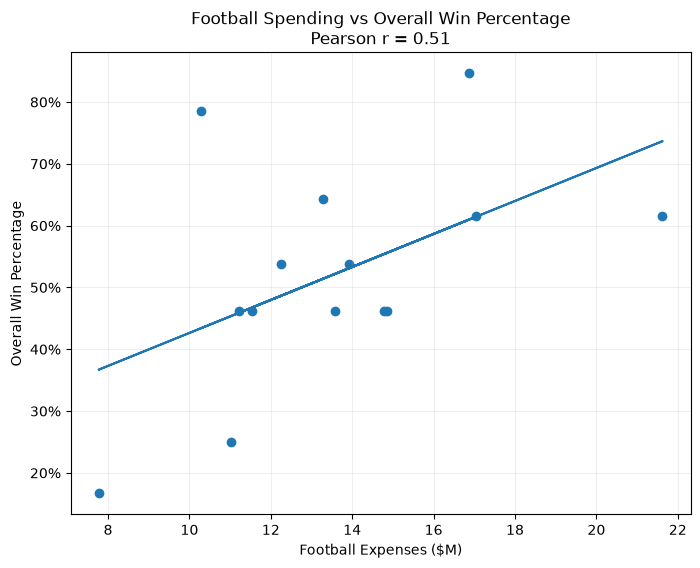

In [16]:
plt.figure(figsize=(8, 6))
x = base_df["football_expenses_millions"]
y = base_df["win_percentage"]

slope, intercept = np.polyfit(x, y, 1)
trendline = slope * x + intercept

plt.scatter(x, y)
plt.plot(x, trendline)

plt.xlabel("Football Expenses ($M)")
plt.ylabel("Overall Win Percentage")

plt.title(
    f"Football Spending vs Overall Win Percentage\n"
    f"Pearson r = {correlation_expenses_win_pct:.2f}"
)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.grid(alpha=0.2)

plt.show()

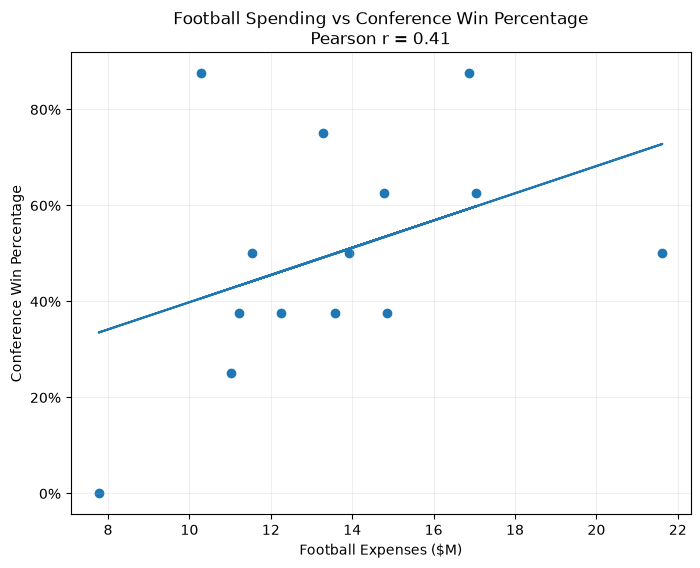

In [17]:
plt.figure(figsize=(8, 6))
x = base_df["football_expenses_millions"]
y = base_df["conference_win_percentage"]

slope, intercept = np.polyfit(x, y, 1)
trendline = slope * x + intercept

plt.scatter(x, y)
plt.plot(x, trendline)

plt.xlabel("Football Expenses ($M)")
plt.ylabel("Conference Win Percentage")

plt.title(
    f"Football Spending vs Conference Win Percentage\n"
    f"Pearson r = {correlation_expenses_conference_win_pct:.2f}"
)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.grid(alpha=0.2)

plt.show()

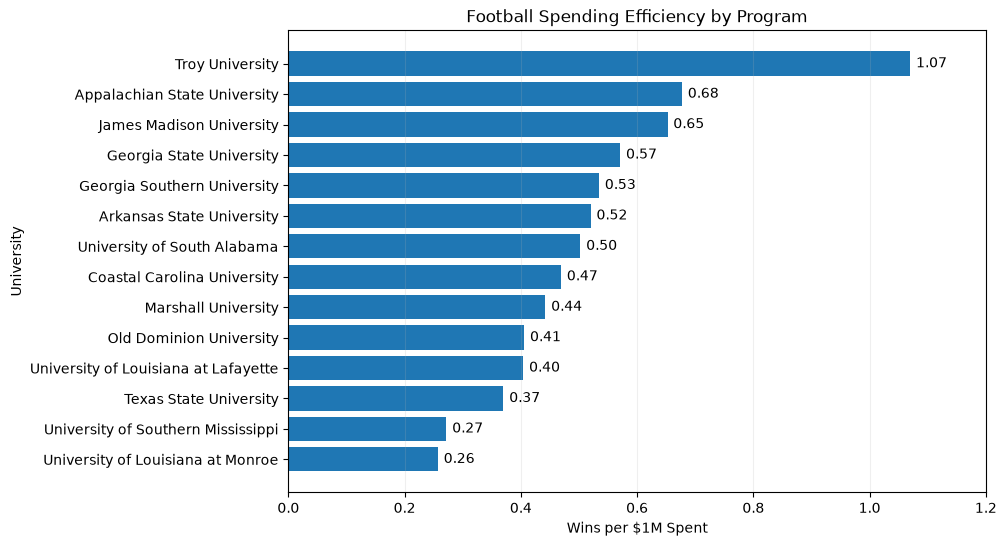

In [18]:
plt.figure(figsize=(9, 6))
efficiency_df = base_df.sort_values(
    "wins_per_million",
    ascending=True
)

plt.barh(
    efficiency_df["university"],
    efficiency_df["wins_per_million"]
)

plt.xlabel("Wins per $1M Spent")
plt.ylabel("University")
plt.title("Football Spending Efficiency by Program")

for index, value in enumerate(efficiency_df["wins_per_million"]):
    plt.text(
        value + 0.01,
        index,
        f"{value:.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.2)
plt.xlim(0, 1.20)

plt.show()

## Key Findings

1. **Football spending and overall performance:** Football spending showed a moderate positive association with overall win percentage across the 14 Sun Belt programs analyzed (Pearson r = 0.51).

2. **Conference performance:** The relationship between football spending and conference win percentage was also positive, but weaker (Pearson r = 0.41).

3. **Spending efficiency:** Troy University ranked first in spending efficiency with 1.07 wins per $1M spent, substantially ahead of Appalachian State University (0.68) and James Madison University (0.65).

4. **James Madison performance:** James Madison University combined strong on-field performance with relatively high spending efficiency, ranking third among the 14 programs in wins per $1M spent.

5. **Spending does not fully explain performance:** Although higher spending was generally associated with stronger performance, substantial differences in efficiency across programs suggest that spending levels alone do not explain competitive success.

## Limitations

- The analysis includes only 14 NCAA Division I Sun Belt football programs, which limits the robustness and generalizability of the results.

- Correlation does not imply causation. The observed relationships between spending and performance are descriptive and should not be interpreted as evidence that higher spending directly causes more wins.

- Football performance can be influenced by factors not included in the dataset, including recruiting quality, coaching, schedule strength, injuries, roster experience, and other program characteristics.

- Financial data and on-field performance data correspond to the periods documented in the project methodology. Differences in reporting periods should be considered when interpreting relationships between spending and performance.

- Wins per $1M spent is a simplified efficiency metric. It measures spending relative to wins but does not capture program revenues, competitive context, long-term investment, or other strategic objectives.

## Conclusion

The analysis suggests that higher football spending is moderately associated with stronger on-field performance across Sun Belt programs, while also revealing substantial differences in spending efficiency. Troy University stands out as the most efficient program in wins per $1M spent, while James Madison University combines strong performance with relatively high spending efficiency.

Overall, the results suggest that financial resources are associated with performance, but how effectively those resources are converted into competitive performance varies significantly across programs.